# Continuous IV and GEX, American Options
American options (exercisable any time), priced with a Cox-Ross-Rubinstein binomial tree, 200 steps.

Compare 3 "Engines"
1. QuantLib (for validation)
2. Numba
3. Numba + CUDA

In [1]:
# uv add jupyter matplotlib numba "numba-cuda[cu13]" "numpy<2.5" polars pyarrow python-dotenv quantlib thetadata tqdm yfinance

import os
import math
import time
import datetime as dt
from concurrent.futures import ThreadPoolExecutor

import numpy as np
import polars as pl
import QuantLib as ql
import yfinance as yf
from tqdm.auto import tqdm
from dotenv import load_dotenv
from thetadata import ThetaClient
from numba import cuda
from numba import float32
from numba import njit
from numba import prange
from numba import vectorize
from zoneinfo import ZoneInfo
import matplotlib.pyplot as plt
from IPython.display import clear_output
from IPython.display import display
from IPython.display import Markdown

### Theta Data for Market Data
https://www.thetadata.net/

In [2]:
# Theta Data
load_dotenv(".env", override=True)
client = ThetaClient(api_key=os.environ["THETADATA_API_KEY"])


def pull_all(request, tickers):
    """Run request(ticker) for every ticker, 8 at a time. A request that fails (for example no data) gives None."""
    def safe(ticker):
        try:
            return request(ticker)
        except Exception:
            return None

    with ThreadPoolExecutor(max_workers=8) as pool:
        return dict(zip(tickers, pool.map(safe, tickers)))

# Market Parameters
* Tickers
* Interval
* Dates

### Tickers: the 100 most options-traded stocks and ETFs
Sources: 
* [<u>Macroption</u> - stocks by options volume](https://www.macroption.com/stock-options-volume/)
* [<u>Macroption</u> - ETFs by options volume](https://www.macroption.com/etf-options-volume/)
* [<u>TipRanks</u> - active stock options](https://www.tipranks.com/options/most-active-stocks-options) 
* [<u>projectoption</u> - active stock options](https://projectoption.com/research/most-active-stock-options)

In [3]:
OPTIONS_VOLUME = pl.DataFrame(
    [
    ("SPY", "ETF", 2760570),  ("QQQ", "ETF", 1534038),  ("NVDA", "stock", 770401),  ("TSLA", "stock", 588277),
    ("IWM", "ETF", 419827),  ("AAPL", "stock", 256663),  ("SLV", "ETF", 217475),  ("AMZN", "stock", 197398),
    ("MSFT", "stock", 193707),  ("IBIT", "ETF", 189894),  ("INTC", "stock", 188672),  ("TLT", "ETF", 171140),
    ("MU", "stock", 167344),  ("PLTR", "stock", 146023),  ("META", "stock", 141715),  ("MSTR", "stock", 140132),
    ("AMD", "stock", 125927),  ("GLD", "ETF", 123519),  ("NFLX", "stock", 115231),  ("GOOGL", "stock", 110078),
    ("SMCI", "stock", 99285),  ("SOFI", "stock", 98821),  ("MARA", "stock", 86827),  ("IREN", "stock", 84853),
    ("SPCX", "stock", 81725),  ("TQQQ", "ETF", 76787),  ("ORCL", "stock", 75731),  ("AVGO", "stock", 72318),
    ("HOOD", "stock", 72254),  ("USO", "ETF", 60718),  ("TSLL", "ETF", 60377),  ("SMH", "ETF", 59799),
    ("SOXL", "ETF", 58438),  ("NOK", "stock", 56459),  ("ETHA", "ETF", 55276),  ("COIN", "stock", 55177),
    ("GDX", "ETF", 54498),  ("GOOG", "stock", 51048),  ("NBIS", "stock", 50136),  ("CRWV", "stock", 49765),
    ("ONDS", "stock", 48802),  ("DRAM", "ETF", 45449),  ("TSM", "stock", 44189),  ("BMNR", "stock", 43812),
    ("BABA", "stock", 42606),  ("SNDK", "stock", 42546),  ("HYG", "ETF", 42401),  ("XLE", "ETF", 41237),
    ("MRVL", "stock", 40916),  ("GME", "stock", 40416),  ("ASTS", "stock", 39897),  ("HIMS", "stock", 38716),
    ("EEM", "ETF", 38686),  ("XLF", "ETF", 37241),  ("KWEB", "ETF", 37076),  ("WULF", "stock", 36052),
    ("CONL", "ETF", 35091),  ("NOW", "stock", 34740),  ("BAC", "stock", 34649),  ("RKLB", "stock", 33349),
    ("OPEN", "stock", 32548),  ("RIVN", "stock", 32024),  ("MRNA", "stock", 30943),  ("WMT", "stock", 30676),
    ("NKE", "stock", 30649),  ("F", "stock", 29857),  ("CRCL", "stock", 29347),  ("AI", "stock", 28693),
    ("SOXS", "ETF", 27963),  ("PFE", "stock", 27841),  ("AAL", "stock", 27297),  ("PYPL", "stock", 26623),
    ("BE", "stock", 26502),  ("CIFR", "stock", 26280),  ("APLD", "stock", 25927),  ("SNAP", "stock", 25923),
    ("IGV", "ETF", 25426),  ("TSLR", "ETF", 23984),  ("NIO", "stock", 23939),  ("UNH", "stock", 23686),
    ("NU", "stock", 23580),  ("QCOM", "stock", 23505),  ("CORZ", "stock", 23462),  ("EWZ", "ETF", 22923),
    ("XOM", "stock", 22491),  ("EWY", "ETF", 22420),  ("RIOT", "stock", 22069),  ("POET", "stock", 21806),
    ("UBER", "stock", 21415),  ("EFA", "ETF", 21247),  ("CRM", "stock", 20785),  ("RGTI", "stock", 19457),
    ("IONQ", "stock", 19432),  ("AMC", "stock", 18644),  ("CVNA", "stock", 18567),  ("BA", "stock", 18443),
    ("EOSE", "stock", 18017),  ("SMR", "stock", 17993),  ("T", "stock", 17531),  ("NVO", "stock", 17189),
    ],
    schema=["ticker", "type", "average_daily_contracts"],
    orient="row",
)

OPTIONS_VOLUME

ticker,type,average_daily_contracts
str,str,i64
"""SPY""","""ETF""",2760570
"""QQQ""","""ETF""",1534038
"""NVDA""","""stock""",770401
"""TSLA""","""stock""",588277
"""IWM""","""ETF""",419827
…,…,…
"""BA""","""stock""",18443
"""EOSE""","""stock""",18017
"""SMR""","""stock""",17993


In [4]:
TICKERS = OPTIONS_VOLUME["ticker"].to_list()   # the 100 most options-traded stocks and ETFs (table above)
print(f"{len(set(TICKERS))} tickers")

REPLAY_DAY = dt.date(2026, 6, 9)       # SPY's widest range in June to September (3.3%), with negative GEX at the prior close

INTERVAL = "1m"                        # option quotes and spot every minute
MAX_DTE = 120                          # options expiring within 120 days
STRIKE_RANGE = None                    # None = every strike (a number keeps that many strikes on each side of spot)
CHAIN = f"dte{MAX_DTE}_strikes{STRIKE_RANGE or 'all'}"   # in the cache file names, so a different chain size downloads again
MIN_TIME_VALUE = 0.05                  # $; options priced at intrinsic value have no well-defined implied vol

FLIP_GRID = np.linspace(0.90, 1.10, 81)   # GEX at 81 prices from -10% to +10% of spot, to find the flip level
CLOSE = 16 * 60                           # 16:00, minutes after midnight
MINUTES_PER_YEAR = 365 * 24 * 60

CACHE_DIR = "gex_history/cache"

market_days = client.stock_list_dates("trade", "SPY")["date"].str.strptime(pl.Date, format="%Y-%m-%d")
PREV_DAY = market_days.filter(market_days < REPLAY_DAY).max()

100 tickers


# Grab & Cache Market Data

### q ( Dividend Yield )

In [5]:
# q (dividend yield)

for ticker in tqdm(TICKERS, desc="dividends"):
    
    file_path = f"{CACHE_DIR}/{ticker.lower()}_dividends_{REPLAY_DAY}.parquet"
    
    if not os.path.exists(file_path):
        dividends = yf.Ticker(ticker).dividends                          # None or empty: no dividends
        if dividends is None or len(dividends) == 0:
            pl.DataFrame({"Date": pl.Series([], dtype=pl.Datetime("ns", "America/New_York")), "Dividends": pl.Series([], dtype=pl.Float64)}).write_parquet(file_path)
        else:
            pl.from_pandas(dividends.reset_index()).write_parquet(file_path)

q = {
    ticker: pl.read_parquet(f"{CACHE_DIR}/{ticker.lower()}_dividends_{REPLAY_DAY}.parquet")
    .select(ex_date=pl.col("Date").dt.date(), dividend=pl.col("Dividends").cast(pl.Float64))
    for ticker in TICKERS
}


def dividend_yield(ticker, day, price):
    """Dividends paid in the 12 months up to day, divided by price."""
    return q[ticker].filter(pl.col("ex_date").is_between(day - dt.timedelta(days=365), day, closed="right"))["dividend"].sum() / price


q["SPY"].tail(3)

dividends:   0%|          | 0/100 [00:00<?, ?it/s]

ex_date,dividend
date,f64
2026-03-20,1.797
2026-06-18,1.904
2026-09-18,1.889


### r ( Risk-Free Rate )

In [6]:
# r - SOFR, percent, risk-free rate: one download from the day before the replay day to today, for the replay and the live session
# SOFR - Secured Overnight Financing Rate. It is based on transactions in the Treasury repurchase market, where investors offer banks overnight loans backed by their bond assets. 
TODAY_ET = dt.datetime.now(ZoneInfo("America/New_York")).date()

file_path = f"{CACHE_DIR}/sofr_{PREV_DAY}_{TODAY_ET}.parquet"

if not os.path.exists(file_path):
    client.interest_rate_history_eod(symbol="SOFR", start_date=PREV_DAY, end_date=TODAY_ET).write_parquet(file_path)

sofr = pl.read_parquet(file_path).select(date=pl.col("created").cast(pl.String).str.slice(0, 10).str.to_date(), rate=pl.col("rate") / 100).sort("date")


def rate_on(day):
    """SOFR on the latest published day up to day (a day's rate is published the next morning)."""
    return sofr.filter(pl.col("date") <= day)["rate"][-1]


r = rate_on(PREV_DAY)
sofr.tail()

date,rate
date,f64
2026-09-27,0.039
2026-09-28,0.039
2026-09-29,0.0388
2026-09-30,0.039
2026-10-01,0.039


### Spots and Options Data

In [7]:
# 1-minute spot and option quotes for the replay day, plus open interest and daily closes

def download_ticker(ticker):
    """Every file the replay needs for one ticker; files already on disk are skipped."""
    t = ticker.lower()
    
    files = {
        f"{CACHE_DIR}/{t}_1m_day_{REPLAY_DAY}.parquet":                     # spot, 1-minute bars
            lambda: client.stock_history_ohlc(symbol=ticker, start_date=REPLAY_DAY, end_date=REPLAY_DAY, interval=INTERVAL),
            
        f"{CACHE_DIR}/{t}_quotes_{INTERVAL}_{REPLAY_DAY}_{CHAIN}.parquet":   # option bid and ask, every minute
            lambda: client.option_history_quote(symbol=ticker, expiration="*", date=REPLAY_DAY, interval=INTERVAL, max_dte=MAX_DTE, strike_range=STRIKE_RANGE),
            
        f"{CACHE_DIR}/{t}_oi_{REPLAY_DAY}_{CHAIN}.parquet":                  # open interest published that morning (positions at the prior close)
            lambda: client.option_history_open_interest(symbol=ticker, expiration="*", date=REPLAY_DAY, max_dte=MAX_DTE, strike_range=STRIKE_RANGE),
            
        f"{CACHE_DIR}/{t}_daily_{PREV_DAY}_{REPLAY_DAY}.parquet":            # official daily close, prior day and replay day
            lambda: client.stock_history_eod(symbol=ticker, start_date=PREV_DAY, end_date=REPLAY_DAY),
    }
    
    for file_path, request in files.items():
        if not os.path.exists(file_path):
            request().write_parquet(file_path)
    return list(files)


downloaded = pull_all(download_ticker, TICKERS)
skipped = [t for t, files in downloaded.items() if files is None]
TICKERS = [t for t in TICKERS if downloaded[t] is not None]
print(f"{len(TICKERS)} tickers with data on {REPLAY_DAY}; skipped (no data): {skipped}")

99 tickers with data on 2026-06-09; skipped (no data): ['SPCX']


### Load Market Data

In [8]:
# load
spot = {t: pl.read_parquet(f"{CACHE_DIR}/{t.lower()}_1m_day_{REPLAY_DAY}.parquet").filter(pl.col("volume") > 0) for t in TICKERS}

quotes = {t: pl.read_parquet(f"{CACHE_DIR}/{t.lower()}_quotes_{INTERVAL}_{REPLAY_DAY}_{CHAIN}.parquet") for t in TICKERS}

oi = {t: pl.read_parquet(f"{CACHE_DIR}/{t.lower()}_oi_{REPLAY_DAY}_{CHAIN}.parquet") for t in TICKERS}

prev_close = {t: pl.read_parquet(f"{CACHE_DIR}/{t.lower()}_daily_{PREV_DAY}_{REPLAY_DAY}.parquet").filter(pl.col("created").dt.date() == PREV_DAY)["close"][0] for t in TICKERS}

print(f"prior close {PREV_DAY}, SOFR {r:.4f}; SPY: {spot['SPY'].height} minutes, {quotes['SPY'].height:,} option quotes, {oi['SPY'].height:,} open interest rows")

prior close 2026-06-08, SOFR 0.0363; SPY: 390 minutes, 3,095,938 option quotes, 7,576 open interest rows


# QuantLib IV and GEX
### Used to validate Numba impl
American (binomial tree, Cox-Ross-Rubinstein, 200 steps) ...   
* price
* gamma
* implied vol  
  
...one option at a time.  

QuantLib counts whole days, so time to expiry is rounded to whole days.  
  
*NOTE* 0DTE are excluded.

In [9]:
# continuous IV & GEX function(s) - QuantLib
TODAY = ql.Date(REPLAY_DAY.day, REPLAY_DAY.month, REPLAY_DAY.year)

ql.Settings.instance().evaluationDate = TODAY

DAY_COUNT = ql.Actual365Fixed()

# builds one American option object
def quantlib_option(S, K, days, r, q, is_call):
    """American option on a 200-step binomial tree, expiring in a whole number of days, QuantLib uses whole days"""
    spot_quote = ql.SimpleQuote(S)
    vol = ql.SimpleQuote(0.2)
    process = ql.BlackScholesMertonProcess(
        ql.QuoteHandle(spot_quote),
        ql.YieldTermStructureHandle(ql.FlatForward(TODAY, q, DAY_COUNT)),
        ql.YieldTermStructureHandle(ql.FlatForward(TODAY, r, DAY_COUNT)),
        ql.BlackVolTermStructureHandle(ql.BlackConstantVol(TODAY, ql.NullCalendar(), ql.QuoteHandle(vol), DAY_COUNT)),
    )
    option = ql.VanillaOption(ql.PlainVanillaPayoff(ql.Option.Call if is_call > 0.5 else ql.Option.Put, K), ql.AmericanExercise(TODAY, TODAY + days))
    option.setPricingEngine(ql.BinomialVanillaEngine(process, "crr", 200))
    return option, spot_quote, vol

# solves IV from mid 
def quantlib_engine(x, n_groups):
    """IV, then GEX at flip prices for every group.  
    Time to expiry is rounded to integers/days, excluded 0DTE"""
    iv = np.full(len(x["K"]), np.nan)
    
    gex_grid = np.zeros((len(FLIP_GRID), n_groups))
    
    for i in range(len(x["K"])):
        days = int(round(x["T"][i] * 365))
        if days < 1:
            continue
        option, spot_quote, vol = quantlib_option(x["S"][i], x["K"][i], days, x["r"][i], x["q"][i], x["is_call"][i])

        def error(sigma):
            vol.setValue(sigma)
            return option.NPV() - x["mid"][i]
        
        ################################################
        ### AMERICAN STYLE IMPLIED VOLATILITY SOLVER ###
        ################################################
        try:
            iv[i] = ql.Brent().solve(error, 1e-8, 0.2, 0.01, 5.0)
        except RuntimeError:
            continue
        vol.setValue(iv[i])
        for j, level in enumerate(x["S"][i] * FLIP_GRID):
            spot_quote.setValue(level)
            gex_grid[j, x["group"][i]] += x["weight"][i] * option.gamma() * level * level
    return iv, gex_grid

# Numba IV and GEX
### https://numba.pydata.org/
American price, gamma and implied vol (200-step binomial tree) in float32 (single precision), compiled by Numba for every CPU core. The GPU cell below compiles the same functions for the GPU.

In [10]:
# continuous IV & GEX function(s) - American binomial tree in float32, compiled by Numba for every CPU core (the next cell compiles the same functions for the GPU)
F = np.float32                                          # float32 constants keep the math in single precision
HALF = F(0.5)
LOW_VOL = F(0.01)
HIGH_VOL = F(5.0)
SIGNATURE = ["float32(float32, float32, float32, float32, float32, float32, float32)"]


STEPS = 200                                             # binomial steps (QuantLib's BinomialVanillaEngine "crr" uses the same tree)
WORK = 201                                              # tree nodes, STEPS + 1: a literal number, because the GPU needs a fixed array size
ZERO = F(0.0)
ONE = F(1.0)
TWO = F(2.0)


@njit
def crr(S, K, T, r, q, sigma, is_call, work):
    """American price and gamma from a Cox-Ross-Rubinstein binomial tree, the same tree as QuantLib's BinomialVanillaEngine "crr"
    (log steps, up-probability from the drift r - q - sigma^2/2); work holds the STEPS + 1 nodes."""
    dt_ = T / F(STEPS)
    dx = sigma * math.sqrt(dt_)
    pu = HALF + HALF * (r - q - HALF * sigma * sigma) * dt_ / dx
    pd = ONE - pu
    disc = math.exp(-r * dt_)
    up2 = math.exp(TWO * dx)
    s = S * math.exp(-F(STEPS) * dx)
    for j in range(STEPS + 1):                          # payoff at expiry
        work[j] = max(s - K, ZERO) if is_call > HALF else max(K - s, ZERO)
        s *= up2
    v0 = ZERO
    v1 = ZERO
    v2 = ZERO
    for step in range(STEPS - 1, -1, -1):               # back through the tree: hold, or exercise early if that is worth more
        s = S * math.exp(-F(step) * dx)
        for j in range(step + 1):
            exercise = max(s - K, ZERO) if is_call > HALF else max(K - s, ZERO)
            work[j] = max(disc * (pu * work[j + 1] + pd * work[j]), exercise)
            s *= up2
        if step == 2:
            v0 = work[0]
            v1 = work[1]
            v2 = work[2]
    s_down = S * math.exp(-TWO * dx)
    s_up = S * math.exp(TWO * dx)
    gamma = ((v2 - v1) / (s_up - S) - (v1 - v0) / (S - s_down)) / (HALF * (s_up - s_down))
    return work[0], gamma


################################################
### AMERICAN STYLE IMPLIED VOLATILITY SOLVER ###
################################################
@njit
def iv_tree(price, S, K, T, r, q, is_call, work):
    # bisection between 1% and 500%; NaN where the price is outside that range
    if price <= crr(S, K, T, r, q, LOW_VOL, is_call, work)[0] or price >= crr(S, K, T, r, q, HIGH_VOL, is_call, work)[0]:
        return F(math.nan)
    lo = LOW_VOL
    hi = HIGH_VOL
    for _ in range(40):
        mid = HALF * (lo + hi)
        if crr(S, K, T, r, q, mid, is_call, work)[0] > price:
            hi = mid
        else:
            lo = mid
    return HALF * (lo + hi)


def iv_one(price, S, K, T, r, q, is_call):
    return iv_tree(price, S, K, T, r, q, is_call, np.empty(WORK, dtype=np.float32))     # CPU: each call gets its own tree nodes


numba_iv = vectorize(SIGNATURE, target="parallel")(iv_one)


@njit(parallel=True)
def numba_gex_grid(S, K, T, r, q, sigma, is_call, weight, group, grid, n_groups):
    """GEX of every group (ticker and minute) at each flip price: one CPU core per price level."""
    out = np.zeros((grid.size, n_groups), dtype=np.float32)
    for j in prange(grid.size):
        work = np.empty(WORK, dtype=np.float32)          # tree nodes for this core
        for i in range(K.size):
            if sigma[i] == sigma[i]:                        # skip options without an implied vol (NaN)
                level = S[i] * grid[j]
                out[j, group[i]] += weight[i] * crr(level, K[i], T[i], r[i], q[i], sigma[i], is_call[i], work)[1] * level * level
    return out


def numba_engine(x, n_groups):
    d = {name: x[name].astype(np.float32) for name in ["mid", "S", "K", "T", "r", "q", "is_call", "weight"]}
    iv = numba_iv(d["mid"], d["S"], d["K"], d["T"], d["r"], d["q"], d["is_call"])
    gex_grid = numba_gex_grid(d["S"], d["K"], d["T"], d["r"], d["q"], iv, d["is_call"], d["weight"], x["group"].astype(np.int32), FLIP_GRID.astype(np.float32), n_groups)
    return iv.astype(np.float64), gex_grid.astype(np.float64)

# Numba CUDA IV and GEX
The same float32 functions, compiled for the GPU. The snapshot is copied to the GPU once; implied vols stay on the GPU and feed the GEX kernel.

In [11]:
# continuous IV & GEX function(s) - Numba CUDA: the float32 functions of the previous cell, compiled for the GPU
cuda.select_device(1)                                   # RTX PRO 6000 Blackwell (device 0 is the RTX 6000 Ada)
def iv_one_gpu(price, S, K, T, r, q, is_call):
    return iv_tree(price, S, K, T, r, q, is_call, cuda.local.array(WORK, float32))      # GPU: each thread gets its own tree nodes


numba_cuda_iv = vectorize(SIGNATURE, target="cuda")(iv_one_gpu)


@cuda.jit
def gex_grid_kernel(S, K, T, r, q, sigma, is_call, weight, group, grid, out):
    """One GPU thread per option and flip price."""
    i, j = cuda.grid(2)
    if i < K.size and j < grid.size and sigma[i] == sigma[i]:
        work = cuda.local.array(WORK, float32)            # tree nodes for this thread
        level = S[i] * grid[j]
        cuda.atomic.add(out, (j, group[i]), weight[i] * crr(level, K[i], T[i], r[i], q[i], sigma[i], is_call[i], work)[1] * level * level)


def numba_cuda_engine(x, n_groups):
    """Copy the snapshot to the GPU once; implied vols stay on the GPU and feed the GEX kernel."""
    d = {name: cuda.to_device(x[name].astype(np.float32)) for name in ["mid", "S", "K", "T", "r", "q", "is_call", "weight"]}
    group = cuda.to_device(x["group"].astype(np.int32))
    grid = cuda.to_device(FLIP_GRID.astype(np.float32))
    iv = numba_cuda_iv(d["mid"], d["S"], d["K"], d["T"], d["r"], d["q"], d["is_call"])
    out = cuda.to_device(np.zeros((len(FLIP_GRID), n_groups), dtype=np.float32))
    blocks = (math.ceil(len(x["K"]) / 128), len(FLIP_GRID))
    gex_grid_kernel[blocks, (128, 1)](d["S"], d["K"], d["T"], d["r"], d["q"], iv, d["is_call"], d["weight"], group, grid, out)
    return iv.copy_to_host().astype(np.float64), out.copy_to_host().astype(np.float64)

# Option Chains for the Whole Day
Every option quote of the replay day, one row per option and minute, with spot at that minute. Each (minute, ticker) pair is a group: one live GEX reading.

In [12]:
minute_of_day = pl.col("timestamp").dt.hour().cast(pl.Int32) * 60 + pl.col("timestamp").dt.minute().cast(pl.Int32)
KEY = ["expiration", "strike", "right"]
OPEN = 9 * 60 + 30

def prepare(frame, open_interest, day, r, q):
    """Option quotes with minute and spot (S) columns -> the engines' columns. Keeps options with a bid, an ask, open interest
    and at least MIN_TIME_VALUE above intrinsic value; time to expiry runs to the close of the expiration day."""
    intrinsic = pl.when(pl.col("right") == "CALL").then(pl.col("S") - pl.col("strike")).otherwise(pl.col("strike") - pl.col("S")).clip(lower_bound=0)
    return (
        frame.filter(pl.col("bid") > 0, pl.col("ask") > 0)
        .join(open_interest.unique(subset=KEY, keep="last").select(KEY + ["open_interest"]), on=KEY)
        .with_columns(mid=(pl.col("bid") + pl.col("ask")) / 2)
        .filter(pl.col("open_interest") > 0, pl.col("mid") - intrinsic > MIN_TIME_VALUE)
        .select(
            "minute",
            "S",
            "mid",
            K=pl.col("strike"),
            T=((pl.col("expiration").str.to_date() - day).dt.total_days() * 1440 + CLOSE - pl.col("minute")).clip(lower_bound=5) / MINUTES_PER_YEAR,
            r=pl.lit(r),
            q=pl.lit(q),
            is_call=(pl.col("right") == "CALL").cast(pl.Float64),
            oi=pl.col("open_interest"),
        )
    )


def ticker_day(ticker):
    """Every quoted option with open interest at every minute of the replay day, with spot at that minute."""
    minute_spot = spot[ticker].select(minute=minute_of_day, S=pl.col("open"))
    frame = quotes[ticker].with_columns(minute=minute_of_day).filter(pl.col("minute") < CLOSE).join(minute_spot, on="minute")
    return prepare(frame, oi[ticker], REPLAY_DAY, r, dividend_yield(ticker, PREV_DAY, prev_close[ticker]))


t0 = time.perf_counter()
day = pl.concat([ticker_day(t).with_columns(ticker=pl.lit(k)) for k, t in enumerate(TICKERS)])
N_GROUPS = (CLOSE - OPEN) * len(TICKERS)                                      # one group per minute and ticker
day = day.with_columns(group=(pl.col("minute") - OPEN) * len(TICKERS) + pl.col("ticker"))
print(f"{REPLAY_DAY}: {day.height:,} option quotes over {day['minute'].n_unique()} minutes and {len(TICKERS)} tickers, built in {time.perf_counter() - t0:.1f} s")


def to_arrays(frame):
    """The engines' input: one NumPy array per column, plus the GEX weight of each option."""
    x = {name: frame[name].cast(pl.Float64).to_numpy() for name in ["S", "mid", "K", "T", "r", "q", "is_call", "oi"]}
    x["group"] = frame["group"].to_numpy()
    x["weight"] = np.where(x["is_call"] > 0.5, 1.0, -1.0) * x["oi"] * 100 * 0.01 / 1e9    # billion $ per 1% move, before gamma x spot^2
    return x


snapshot = to_arrays(day.filter(pl.col("minute") == 10 * 60))                # one minute: 10:00
full_day = to_arrays(day.filter(pl.col("minute").is_between(10 * 60, 10 * 60 + 9)))   # 10 minutes, 10:00 to 10:09 (American is slow on the CPU)
print(f"10:00 snapshot {len(snapshot['K']):,} options; 10 minutes {len(full_day['K']):,} options")

2026-06-09: 33,384,516 option quotes over 390 minutes and 99 tickers, built in 6.3 s
10:00 snapshot 85,814 options; 10 minutes 856,340 options


In [13]:
ENGINES = {
    "QuantLib": quantlib_engine,
    "Numba": numba_engine,
    "Numba CUDA": numba_cuda_engine,
}

# Compare Numba / Numba + CUDA to QuantLib

In [14]:
# 

# validate Numba and Numba CUDA against QuantLib: SPY at 10:00 (QuantLib takes about 17 minutes for every ticker)
# QuantLib counts whole days: every engine gets whole-day times, and options expiring today are left out
whole_days = np.round(snapshot["T"] * 365)
keep = (whole_days >= 1) & (snapshot["group"] == (10 * 60 - OPEN) * len(TICKERS))   # SPY's options at 10:00
same_input = {name: values[keep] for name, values in snapshot.items()}
same_input["T"] = whole_days[keep] / 365
results = {engine: ENGINES[engine](same_input, N_GROUPS) for engine in ENGINES}
at_10 = (10 * 60 - OPEN) * len(TICKERS) + np.arange(len(TICKERS))            # the 10:00 group of each ticker

iv_ql, grid_ql = results["QuantLib"]
rows = []
for engine, (iv, grid) in results.items():
    ok = ~np.isnan(iv) & ~np.isnan(iv_ql)
    difference = np.abs(grid[:, at_10] - grid_ql[:, at_10]).max(axis=0) / np.abs(grid_ql[:, at_10]).max(axis=0)   # per ticker, relative to its largest GEX
    rows.append({
        "engine": engine,
        "implied vol solved": int((~np.isnan(iv)).sum()),
        "implied vol, largest difference": np.max(np.abs(iv[ok] - iv_ql[ok])),
        "implied vol, median difference": np.median(np.abs(iv[ok] - iv_ql[ok])),
        "SPY GEX at spot, billion $": grid[len(FLIP_GRID) // 2, at_10[0]],
        "GEX over 81 prices, largest difference, % (worst ticker)": np.nanmax(difference) * 100,
        "GEX over 81 prices, largest difference, % (median ticker)": np.nanmedian(difference) * 100,
    })
pl.DataFrame(rows)

/home/will/git/GPU-Quant-Finance/05-pytorch-options-scanning/.venv/lib/python3.12/site-packages/numba_cuda/numba/cuda/dispatcher.py:748: NumbaPerformanceWarning: Grid size 5 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))
/tmp/ipykernel_337751/2668186617.py:16: RuntimeWarning: invalid value encountered in divide
  difference = np.abs(grid[:, at_10] - grid_ql[:, at_10]).max(axis=0) / np.abs(grid_ql[:, at_10]).max(axis=0)   # per ticker, relative to its largest GEX


engine,implied vol solved,"implied vol, largest difference","implied vol, median difference","SPY GEX at spot, billion $","GEX over 81 prices, largest difference, % (worst ticker)","GEX over 81 prices, largest difference, % (median ticker)"
str,i64,f64,f64,f64,f64,f64
"""QuantLib""",4925,0.0,0.0,-4.395259,0.0,0.0
"""Numba""",4923,0.017421,0.00001,-4.393868,0.022058,0.022058
"""Numba CUDA""",4923,0.055975,0.000015,-4.39545,0.0543,0.0543


# Timing: One Minute and 10 Minutes

In [15]:
# time each engine: one 10:00 snapshot, and 10 minutes (10:00 to 10:09) in one call
numba_engine(snapshot, N_GROUPS)                  # compile before timing
numba_cuda_engine(snapshot, N_GROUPS)
spy_10 = {name: values[snapshot["group"] == at_10[0]] for name, values in snapshot.items()}   # SPY at 10:00

timings = []
for engine in ENGINES:
    if engine == "QuantLib":                      # QuantLib on SPY only, scaled up to every ticker (the full minute takes about 17 minutes)
        t0 = time.perf_counter()
        ENGINES[engine](spy_10, N_GROUPS)
        one_minute = (time.perf_counter() - t0) * len(snapshot["K"]) / len(spy_10["K"])
        ten_minutes = one_minute * 10
    else:
        t0 = time.perf_counter()
        ENGINES[engine](snapshot, N_GROUPS)
        one_minute = time.perf_counter() - t0
        t0 = time.perf_counter()
        ENGINES[engine](full_day, N_GROUPS)
        ten_minutes = time.perf_counter() - t0
    timings.append({"engine": engine, "one minute, seconds": one_minute, "10 minutes, seconds": ten_minutes, "measured": engine != "QuantLib"})
timings = pl.DataFrame(timings).with_columns(speedup_over_quantlib=pl.col("10 minutes, seconds").first() / pl.col("10 minutes, seconds"))
print(f"10 minutes: {len(full_day['K']):,} options x {len(FLIP_GRID)} prices = {len(full_day['K']) * len(FLIP_GRID):,} gamma evaluations")
timings

/home/will/git/GPU-Quant-Finance/05-pytorch-options-scanning/.venv/lib/python3.12/site-packages/numba_cuda/numba/cuda/dispatcher.py:748: NumbaPerformanceWarning: Grid size 84 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))


10 minutes: 856,340 options x 81 prices = 69,363,540 gamma evaluations


engine,"one minute, seconds","10 minutes, seconds",measured,speedup_over_quantlib
str,f64,f64,bool,f64
"""QuantLib""",993.39626,9933.962595,false,1.0
"""Numba""",5.250069,51.591954,true,192.548679
"""Numba CUDA""",0.69569,7.140086,true,1391.294599


# Live Session
Run the next cell once after the open. Open interest is published once a day (positions at the prior close), so it is pulled once; spot and option quotes are pulled live in every update.

In [16]:
# live session setup: run once after the open
LIVE_TICKERS = OPTIONS_VOLUME["ticker"].to_list()
REFRESH_SECONDS = 60                   # one update a minute
NEAR_FLIP_PCT = 0.5                    # alert: spot within 0.5% of its flip level
MIN_GEX = 0.05                         # billion $ per 1%: tickers whose GEX never reaches this over the 81 prices are too small to alert on
IV_JUMP = 2.0                          # alert: at-the-money implied vol moves 2 vol points in one update
ET = ZoneInfo("America/New_York")
LIVE_DAY = dt.datetime.now(ET).date()


live_oi = pull_all(lambda t: client.option_snapshot_open_interest(symbol=t, expiration="*", max_dte=MAX_DTE), LIVE_TICKERS)
live_oi = {t: frame for t, frame in live_oi.items() if frame is not None}
LIVE_TICKERS = [t for t in LIVE_TICKERS if t in live_oi]
live_r = rate_on(LIVE_DAY)
print(f"{LIVE_DAY}: open interest for {len(LIVE_TICKERS)} tickers, SOFR {live_r:.4f}")


def live_snapshot():
    """Live spot and option quotes for every ticker, as engine arrays (one group per ticker)."""
    now = dt.datetime.now(ET)
    minute = now.hour * 60 + now.minute
    spot_frame = client.stock_snapshot_quote(symbol=LIVE_TICKERS)
    spots = dict(zip(spot_frame["symbol"], (spot_frame["bid"] + spot_frame["ask"]) / 2))
    chains = pull_all(lambda t: client.option_snapshot_quote(symbol=t, expiration="*", max_dte=MAX_DTE), LIVE_TICKERS)
    frames = []
    for k, (ticker, chain) in enumerate(chains.items()):
        if chain is None or ticker not in spots:
            continue
        S = float(spots[ticker])
        frame = chain.with_columns(minute=pl.lit(minute), S=pl.lit(S))
        frames.append(prepare(frame, live_oi[ticker], LIVE_DAY, live_r, dividend_yield(ticker, LIVE_DAY, S)).with_columns(group=pl.lit(k)))
    return to_arrays(pl.concat(frames)), now


def flip_level(levels, g, S):
    """Price where GEX changes sign nearest to spot, a straight line between the two grid prices; NaN if none."""
    crossings = np.where(np.sign(g[:-1]) != np.sign(g[1:]))[0]
    if len(crossings) == 0:
        return np.nan
    i = crossings[np.argmin(np.abs(levels[crossings] - S))]
    return levels[i] - g[i] * (levels[i + 1] - levels[i]) / (g[i + 1] - g[i])


def live_table(x, iv, gex_grid, now):
    """One row per ticker: spot, GEX at spot, flip level, distance to flip, at-the-money implied vol."""
    rows = []
    for k, ticker in enumerate(LIVE_TICKERS):
        mine = x["group"] == k
        if not mine.any():
            continue
        S = x["S"][mine][0]
        flip = flip_level(S * FLIP_GRID, gex_grid[:, k], S)
        later = mine & (x["T"] >= 1 / 365) & ~np.isnan(iv)        # at-the-money: nearest strike of the nearest expiry at least a day out
        atm_iv = np.nan
        if later.any():
            pick = later & (x["T"] == x["T"][later].min())
            atm_iv = iv[pick][np.argmin(np.abs(x["K"][pick] - S))] * 100
        rows.append({"time": f"{now:%H:%M}", "ticker": ticker, "spot": S, "gex": gex_grid[len(FLIP_GRID) // 2, k], "flip": flip,
                     "distance_to_flip_pct": (S / flip - 1) * 100, "atm_iv_pct": atm_iv, "gex_size": np.abs(gex_grid[:, k]).max()})
    return pl.DataFrame(rows)


def alerts(table, before=None):
    """What changed since the previous update, as three yes/no columns: GEX changed sign, spot moved into the near-flip band,
    at-the-money implied vol jumped. Tickers with little gamma (GEX size under MIN_GEX) are left out.
    With no previous update, every ticker in the band is reported."""
    if before is None:
        before = table.clear()
    near = pl.col("distance_to_flip_pct").abs() < NEAR_FLIP_PCT
    return (
        table.join(before.select("ticker", gex_before="gex", iv_before="atm_iv_pct", near_before=near), on="ticker", how="left")
        .filter(pl.col("gex_size") > MIN_GEX)
        .with_columns(
            gex_changed_sign=(pl.col("gex").sign() != pl.col("gex_before").sign()).fill_null(False),
            moved_near_flip=(near & ~pl.col("near_before").fill_null(False)).fill_null(False),
            iv_jump=((pl.col("atm_iv_pct") - pl.col("iv_before")).abs() > IV_JUMP).fill_null(False),
        )
        .filter(pl.col("gex_changed_sign") | pl.col("moved_near_flip") | pl.col("iv_jump"))
        .select("ticker", "gex_changed_sign", "moved_near_flip", "iv_jump", "spot", "gex", "flip", "distance_to_flip_pct", "atm_iv_pct")
    )

2026-10-01: open interest for 100 tickers, SOFR 0.0390


The first chart shows the 5 most options-traded tickers, the 5 with the largest GEX and the 5 nearest their flip level, each on its own scale; red bars had an alert at the latest update, green bars have positive GEX (moves tend to be damped), grey bars negative GEX (moves tend to be amplified). The second chart follows GEX through the session for the first 10, one lane per ticker on its own scale. Stop the loop with the interrupt button; the history is kept.

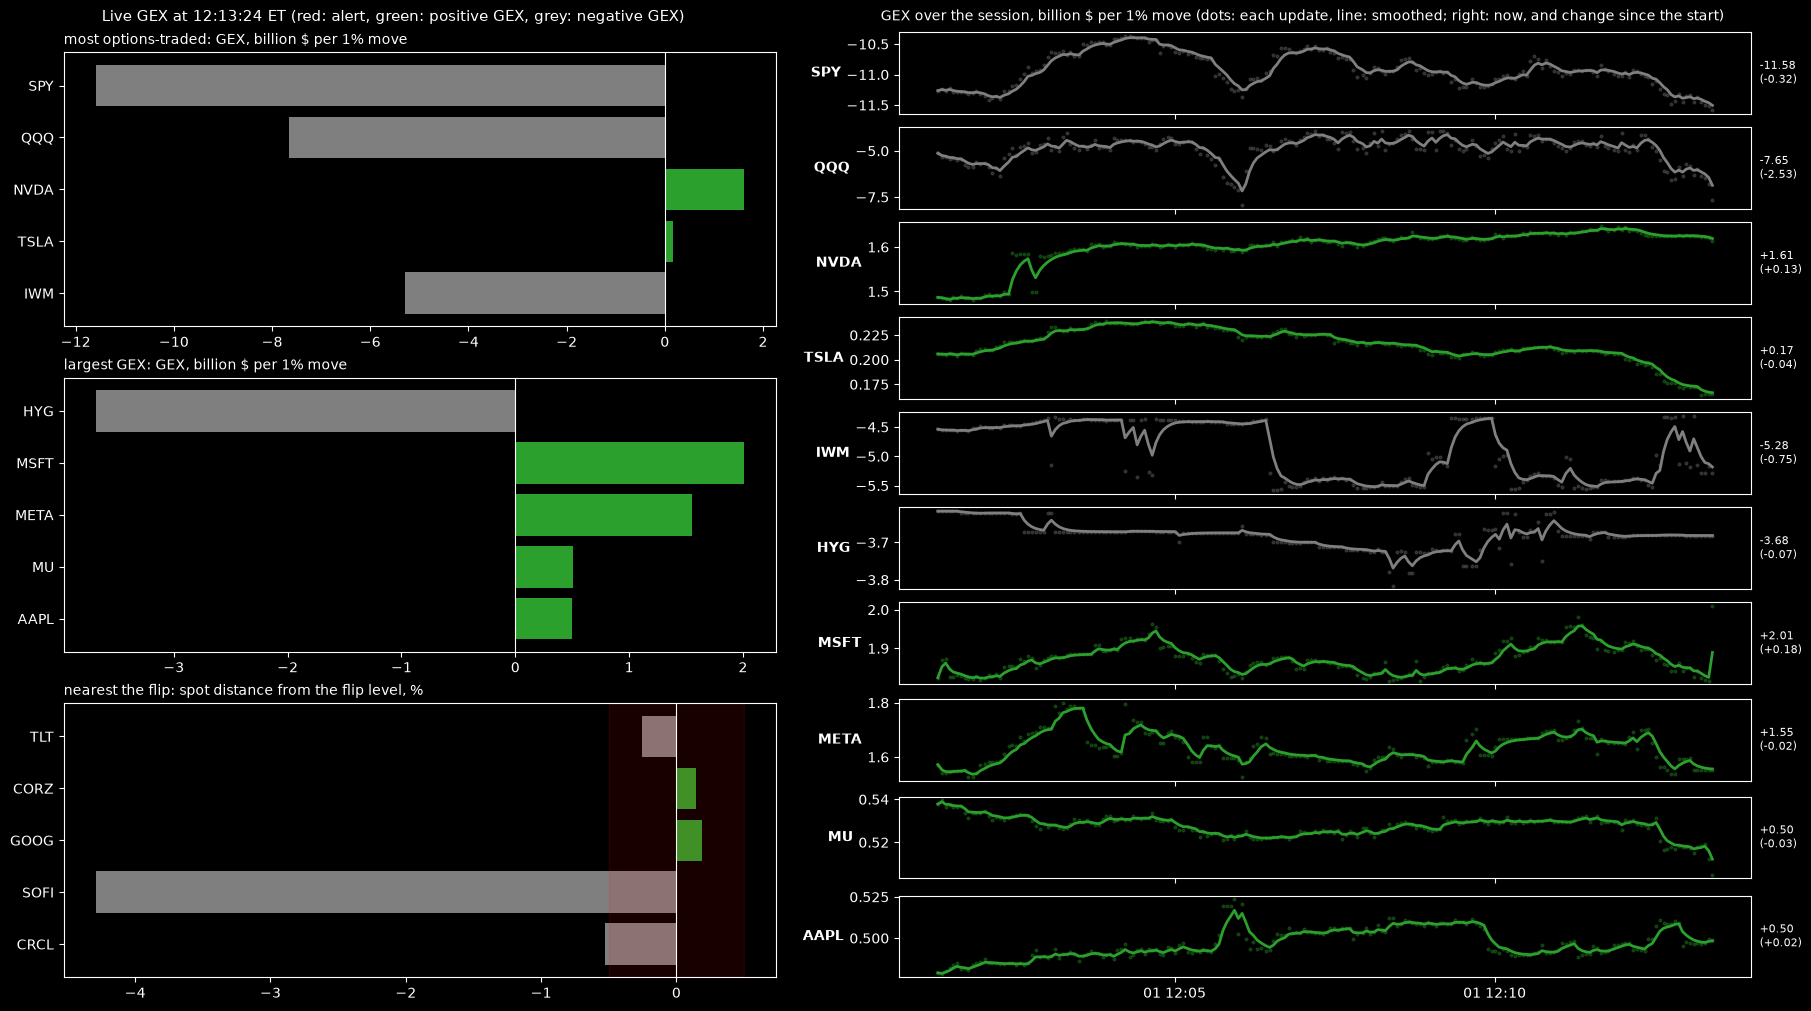

100 tickers, 82,507 options; live data 2.2 s, GPU 0.662 s

ticker,flipped_to,flipped_at,minutes_ago,flips_in_10_minutes
str,str,str,f64,u32
"""GOOGL""","""positive""","""12:13:13""",0.2,18
"""SOXS""","""positive""","""12:12:48""",0.6,59
"""USO""","""negative""","""12:10:33""",2.8,1
"""TLT""","""negative""","""12:08:03""",5.3,8


ticker,gex_changed_sign,moved_near_flip,iv_jump,spot,gex,flip,distance_to_flip_pct,atm_iv_pct
str,bool,bool,bool,f64,f64,f64,f64,f64
"""NFLX""",false,false,true,67.945,-0.045995,70.760306,-3.978652,32.118595
"""USO""",false,false,true,147.63,-0.005597,148.058249,-0.289243,57.46299
"""GDX""",false,false,true,87.545,-0.067718,95.957389,-8.766797,49.670011
"""BABA""",false,false,true,107.04,-0.007782,107.718057,-0.629474,38.27166
"""XLE""",false,false,true,62.305,-0.081134,65.018567,-4.173526,28.041053
"""MRVL""",false,false,true,265.045,0.123966,NaN,NaN,67.855453
"""EEM""",false,false,true,66.345,-0.043659,67.515115,-1.733116,28.573281
"""UNH""",false,false,true,363.39,-0.116552,384.157371,-5.405954,42.885023
"""XOM""",false,false,true,163.47,0.106217,148.97406,9.730513,29.568487


/home/will/git/GPU-Quant-Finance/05-pytorch-options-scanning/.venv/lib/python3.12/site-packages/numba_cuda/numba/cuda/dispatcher.py:748: NumbaPerformanceWarning: Grid size 81 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))
/home/will/git/GPU-Quant-Finance/05-pytorch-options-scanning/.venv/lib/python3.12/site-packages/numba_cuda/numba/cuda/dispatcher.py:748: NumbaPerformanceWarning: Grid size 80 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))


In [ ]:
# live chart: updates back to back until the close; three charts redraw each time
FLIP_WINDOW = dt.timedelta(minutes=10)   # list flips from the last 10 minutes
N = 5                                    # tickers per chart
SMOOTH = 0.35                            # timeline line: exponential moving average weight of the newest update
TOP = OPTIONS_VOLUME.sort("average_daily_contracts", descending=True)["ticker"].head(N).to_list()   # SPY, QQQ, NVDA, TSLA, IWM
big = None                               # rows of each chart, set at the first update and then fixed
near = None
history = []
flips = []                               # every GEX sign change today: ticker, time, new sign
before = None
plt.style.use("dark_background")          # black background, light text and lines
# fixed output slots, updated in place each update (no clearing, so nothing flashes)
bars_view = display(Markdown("waiting for the first update..."), display_id=True)
status_view = display(Markdown(""), display_id=True)
flips_view = display(Markdown(""), display_id=True)
alerts_view = display(Markdown(""), display_id=True)
while dt.datetime.now(ET).hour * 60 + dt.datetime.now(ET).minute < CLOSE:
    t0 = time.perf_counter()
    x, now = live_snapshot()
    t1 = time.perf_counter()
    iv, gex_grid = numba_cuda_engine(x, len(LIVE_TICKERS))
    t2 = time.perf_counter()
    table = live_table(x, iv, gex_grid, now).with_columns(at=pl.lit(now))
    found = alerts(table, before)
    history.append(table)
    before = table

    if big is None:                                       # first update: largest GEX, then nearest the flip
        big = table.filter(~pl.col("ticker").is_in(TOP)).sort(pl.col("gex").abs(), descending=True)["ticker"].head(N).to_list()
        near = (table.filter(~pl.col("ticker").is_in(TOP + big), pl.col("distance_to_flip_pct").is_finite())
                .sort(pl.col("distance_to_flip_pct").abs())["ticker"].head(N).to_list())

    for row in found.filter(pl.col("gex_changed_sign")).iter_rows(named=True):
        flips.append({"ticker": row["ticker"], "time": now, "gex_now": "negative" if row["gex"] < 0 else "positive"})
    recent = [{"ticker": f["ticker"], "flipped_to": f["gex_now"], "flipped_at": f"{f['time']:%H:%M:%S}",
               "minutes_ago": round((now - f["time"]).total_seconds() / 60, 1)}
              for f in flips if now - f["time"] <= FLIP_WINDOW]

    distance = dict(zip(table["ticker"], table["distance_to_flip_pct"]))
    gex = dict(zip(table["ticker"], table["gex"]))
    flagged = set(found["ticker"])

    fig = plt.figure(figsize=(18, 10), layout="constrained")
    left, right = fig.subfigures(1, 2, width_ratios=[1, 1.3])   # left: bar charts, right: GEX over the session
    axes = left.subplots(3, 1)
    charts = [
        (TOP, gex, "most options-traded: GEX, billion $ per 1% move"),
        (big, gex, "largest GEX: GEX, billion $ per 1% move"),
        (near, distance, "nearest the flip: spot distance from the flip level, %"),
    ]
    for ax, (tickers, values, title) in zip(axes, charts):
        colors = ["red" if t in flagged else ("tab:green" if gex.get(t, 0) > 0 else "tab:gray") for t in tickers]
        ax.barh(tickers, [values.get(t, np.nan) for t in tickers], color=colors)
        ax.invert_yaxis()                                 # first ticker at the top
        ax.axvline(0, color="white", linewidth=0.8)
        ax.set_title(title, loc="left", fontsize=10)
    axes[2].axvspan(-NEAR_FLIP_PCT, NEAR_FLIP_PCT, color="red", alpha=0.1)
    left.suptitle(f"Live GEX at {now:%H:%M:%S} ET (red: alert, green: positive GEX, grey: negative GEX)", fontsize=11)

    # right: GEX over the session, one lane per ticker, each on its own scale
    lanes = TOP + big
    past = pl.concat(history).filter(pl.col("ticker").is_in(lanes)).sort("at")
    axes2 = right.subplots(len(lanes), 1, sharex=True)
    for ax, ticker in zip(axes2, lanes):
        one = past.filter(pl.col("ticker") == ticker).with_columns(smooth=pl.col("gex").ewm_mean(alpha=SMOOTH))
        color = "tab:green" if one["gex"][-1] > 0 else "tab:gray"
        ax.scatter(one["at"].to_list(), one["gex"], s=4, color=color, alpha=0.3)
        ax.plot(one["at"].to_list(), one["smooth"], color=color, linewidth=2)
        if one["gex"].min() < 0 < one["gex"].max():
            ax.axhline(0, color="white", linewidth=0.6)   # zero line only when the lane crosses it, so each lane keeps its own scale
        ax.set_ylabel(ticker, rotation=0, ha="right", va="center", fontweight="bold")
        ax.text(1.01, 0.5, f"{one['gex'][-1]:+.2f}\n({one['gex'][-1] - one['gex'][0]:+.2f})", transform=ax.transAxes, va="center", fontsize=8)
    right.suptitle("GEX over the session, billion $ per 1% move (dots: each update, line: smoothed; right: now, and change since the start)", fontsize=10)
    bars_view.update(fig)
    plt.close(fig)
    status_view.update(Markdown(f"{len(LIVE_TICKERS)} tickers, {len(x['K']):,} options; live data {t1 - t0:.1f} s, GPU {t2 - t1:.3f} s"))
    if recent:
        flips_view.update(pl.DataFrame(recent).sort("flipped_at", descending=True)
                          .group_by("ticker", maintain_order=True)
                          .agg(pl.col("flipped_to").first(), pl.col("flipped_at").first(), pl.col("minutes_ago").first(), flips_in_10_minutes=pl.len()))
    else:
        flips_view.update(Markdown("No GEX flips in the last 10 minutes"))
    alerts_view.update(found)